# mmap python rdma

## Contents

* [mmap python rdma](#mmap-python-rdma)
* [Google Search Title:](#google-search-title)
* [Google Search AI Overview:](#google-search-ai-overview)
* [1. Create a memory-mapped buffer (e.g., for a file)](#1-create-a-memory-mapped-buffer-eg-for-a-file)
* [Map the file into memory](#map-the-file-into-memory)
* [2. Register the mmap buffer with the RDMA stack](#2-register-the-mmap-buffer-with-the-rdma-stack)
* [(Specific API call will be in the python-rdma documentation)](#specific-api-call-will-be-in-the-python-rdma-documentation)
* [pd = ... # Get a Protection Domain object](#pd-get-a-protection-domain-object)
* [mr = pd.reg_mr(mm) # Register the mmap object as a Memory Region](#mr-pdreg_mrmm-register-the-mmap-object-as-a-memory-region)
* [3. Use the MR for RDMA operations](#3-use-the-mr-for-rdma-operations)
* [qp = ... # Get a Queue Pair object](#qp-get-a-queue-pair-object)
* [qp.post_recv(mr, ...)](#qppost_recvmr-)
* [qp.post_send(mr, ...)](#qppost_sendmr-)
* [... RDMA communication logic ...](#-rdma-communication-logic-)
* [Close the mmap object (unmaps the memory)](#close-the-mmap-object-unmaps-the-memory)

Google Search Title:
====================

mmap python rdma


Google Search AI Overview:
==========================


The

`mmap` module in Python can be used with RDMA by registering the memory-mapped regions with the RDMA stack, typically via the `python-rdma` library. This allows RDMA operations to directly access data in the memory-mapped buffer, bypassing extra data copies between the application and the OS kernel, which is a key benefit of RDMA. 

Key Components 

*   **`mmap` Module**: The built-in [Python `mmap` module](https://docs.python.org/3/library/mmap.html) provides an interface to the operating system's `mmap` system call, which maps a file or anonymous memory into a process's virtual address space.
*   **`python-rdma` Library**: This third-party library provides a Python API for the Linux RDMA stack (libibverbs, etc.). It allows you to manage RDMA resources like Protection Domains (PD), Memory Regions (MR), and Queue Pairs (QP). 

How it Works 

To use `mmap` memory with RDMA in Python, the general process involves: 

1.  **Allocate Memory with `mmap`**: Use the Python `mmap` module to create a memory buffer, either backed by a file or as anonymous memory for inter-process communication (IPC).
2.  **Register as an RDMA Memory Region (MR)**: The virtual memory address obtained from `mmap` must be registered with the RDMA device through the `python-rdma` library's APIs. This registration process involves "pinning" the memory pages in physical RAM so they are not swapped out, which is necessary for the NIC (Network Interface Card) to perform direct memory access.
3.  **Perform RDMA Operations**: Once the memory region is registered, the buffer can be used as the target or source for zero-copy RDMA operations (e.g., RDMA Read, Write, Send). The NIC then translates the virtual addresses to physical addresses and transfers data directly. 

Benefits 

*   **Zero-Copy Networking**: The primary advantage is eliminating unnecessary data copies between the application's buffer and the kernel's network buffers, leading to higher performance and lower latency.
*   **Efficient I/O**: `mmap` itself is an efficient way to handle large files or shared memory, and combining it with RDMA leverages this efficiency for network operations. 

Example (Conceptual) 

While specific implementation details depend on the `python-rdma` version, the core idea is to obtain the memory buffer from the `mmap` object and use the library's `register_mr` (Memory Region) equivalent function. 

python

    import mmap
    import rdma  # This requires the python-rdma library

    # 1. Create a memory-mapped buffer (e.g., for a file)
    with open("large_data.bin", "r+b") as f:
        # Map the file into memory
        mm = mmap.mmap(f.fileno(), 0) # 0 means map the entire file

        # 2. Register the mmap buffer with the RDMA stack
        # (Specific API call will be in the python-rdma documentation)
        # pd = ... # Get a Protection Domain object
        # mr = pd.reg_mr(mm) # Register the mmap object as a Memory Region

        # 3. Use the MR for RDMA operations
        # qp = ... # Get a Queue Pair object
        # qp.post_recv(mr, ...)
        # qp.post_send(mr, ...)

        # ... RDMA communication logic ...

        # Close the mmap object (unmaps the memory)
        mm.close()


Copied to clipboard

For official documentation and usage examples of the `python-rdma` library, refer to its [GitHub repository](https://github.com/jgunthorpe/python-rdma). 

*   [](https://github.com/jgunthorpe/python-rdma#:~:text=This%20package%20contains%20the%20Python,code%20is%20available%20on%20GitHub.)

    jgunthorpe/python-rdma - GitHub

    Aug 21, 2017 — This package contains the Python module rdma which provides a Python API for the Linux RDMA stack. It is an amalgamation of the fu...

    

    GitHub

    

*   [](https://stackoverflow.com/questions/33971851/what-happens-when-rdma-operates-over-mmaped-region)

    What happens when RDMA operates over mmaped region?

    Nov 28, 2015 — What happens when RDMA operates over mmaped region? ... RDMA is an efficient way to bypass the useless data copies between applica...

    

    Stack Overflow

*   [](https://www.oracle.com/database/technologies/exadata/hardware/rdmanetwork/#:~:text=RDMA%20\(Remote%20Direct%20Memory%20Access,and%20with%20very%20low%20latency.)

    RDMA Network Fabric | Oracle Exadata Database Machine

    RDMA (Remote Direct Memory Access) allows one computer to directly access data from another without operating system or CPU involv...

    

    Oracle

*   [](https://docs.python.org/3/library/mmap.html#:~:text=In%20either%20case%20you%20must%20provide%20a,file%20object%2C%20use%20its%20fileno\(\)%20method%20to)

    mmap — Memory-mapped file support — Python 3.14.3 ...

    Mar 7, 2026 — In either case you must provide a file descriptor for a file opened for update. If you wish to map an existing Python file object,

    

    Python documentation

    

*   [](https://www.reddit.com/r/C_Programming/comments/j1dxpu/python_mmap_mlock_wrapper/#:~:text=Hi%20!,Thanks%20!)

    Python mmap / mlock wrapper : r/C\_Programming - Reddit

    Sep 28, 2020 — Hi ! I'm running a python 3.8 program that is in charge of manipulating cryptographic materials (keys gen, encrypt, decrypt). And ...

    

    Reddit

*   [](https://realpython.com/python-mmap/#:~:text=Python's%20mmap%20provides%20memory%2Dmapped,lot%20of%20file%20I/O.)

    Python mmap: Improved File I/O With Memory Mapping

    Aug 24, 2020 — Python mmap: Improved File I/O With Memory Mapping. ... The Zen of Python has a lot of wisdom to offer. One especially useful idea...

    

    Real Python

    

*   [](https://github.com/offchan42/python-mmap-ipc#:~:text=This%20repository%20is%20an%20example,from%20one%20process%20to%20another.)

    GitHub - offchan42/python-mmap-ipc: :zap: Fast inter-process ...

    This repository is an example on how to do fast inter-process communication using memory mapped file in python. It is designed to ...

    

    GitHub

    

*   [](https://en.wikipedia.org/wiki/Mmap#:~:text=In%20computing%2C%20mmap\(2\),no%20physical%20RAM%20at%20all.)

    mmap - Wikipedia

    In computing, mmap(2) is a POSIX-compliant Unix system call that maps files or devices into memory. It is a method of memory-mappe...

    

    Wikipedia

*   [](https://programmingappliedai.substack.com/p/what-is-mmap-in-linux-and-how-it)

    What is MMAP in Linux and how it is useful?

    Dec 30, 2024 — mmap (memory-mapped file) is a system call that maps a file or a portion of it into a process's virtual memory space. ... This all...

    

    Substack

    

*   [](https://stackoverflow.com/questions/33971851/what-happens-when-rdma-operates-over-mmaped-region#:~:text=1%20Answer.%20Yes%2C%20you%20can%20register%20with,be%20registered%2C%20including%2C%20but%20not%20limited%20to:)

    What happens when RDMA operates over mmaped region?

    Nov 28, 2015 — 1 Answer. Yes, you can register with RDMA a region of memory mapped using mmap() . See the docs for ibv\_reg\_mr (http://www.rdmamoj...

    ![](https://encrypted-tbn3.gstatic.com/faviconV2?url=https://stackoverflow.com&client=AIM&size=128&type=FAVICON&fallback_opts=TYPE,SIZE,URL)

    Stack Overflow

*   [](https://www.ibm.com/docs/pl/aix/7.3.0?topic=m-mmap-mmap64-subroutine#:~:text=The%20mmap%20subroutine%20creates%20a%20new%20mapped,if%20the%20program%20attempts%20to%20map%20itself.)

    mmap or mmap64 Subroutine

    The mmap subroutine creates a new mapped file or anonymous memory region by establishing a mapping between a process-address space...

    ![](https://encrypted-tbn2.gstatic.com/faviconV2?url=https://www.ibm.com&client=AIM&size=128&type=FAVICON&fallback_opts=TYPE,SIZE,URL)

    IBM

*   [](https://www.youtube.com/watch?v=ky1n6luzL3Y)

    File I/O With Memory Mapping Using Python mmap

    Jun 23, 2022 — welcome to python mmap doing file i o with memory mapping my name is christopher. and i will be your guide. this course is about t...

    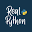

    

    YouTube·Real Python

    ![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR1m8W7PR3GEm6PR-vkWxBlI7wIaqAgDmT_pvOSteMBI3_JNSvn)

    23:02

*   [](https://docs.nvidia.com/networking/display/public/sol/howto+configure+pvrdma+in+vmware+vsphere+6-5+and+6-7#:~:text=Zero%2Dcopy%20%2D%20Allows%20applications%20to%20perform%20data,without%20being%20copied%20between%20the%20network%20layers.)

    HowTo Configure PVRDMA in VMware vSphere 6.5 and 6.7 - NVIDIA Docs

    Aug 8, 2019 — Zero-copy - Allows applications to perform data transfers without involving the network software stack. Data is sent and received ...

    ![](https://encrypted-tbn0.gstatic.com/faviconV2?url=https://docs.nvidia.com&client=AIM&size=128&type=FAVICON&fallback_opts=TYPE,SIZE,URL)

    NVIDIA Docs

    ![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTBzVpCkE1ePa0IL_TvTJP8iKP6qwnawwsKK4TsGCcSZWivTuEU)

*   [](https://www.linkedin.com/pulse/rdma-networking-trends-rakesh-cheerla-izpuc#:~:text=Low%20Latency%20and%20Memory%20Efficiency:%20RDMA%20bypasses,and%20zero%2Dcopy%20features%20minimize%20latency%20and%20jitter.)

    RDMA Networking Trends - Rakesh Cheerla

    Oct 12, 2023 — Low Latency and Memory Efficiency: RDMA bypasses the Linux kernel and directly transfers data to application buffers, a feature kn...

    ![](https://encrypted-tbn2.gstatic.com/faviconV2?url=https://www.linkedin.com&client=AIM&size=128&type=FAVICON&fallback_opts=TYPE,SIZE,URL)

    LinkedIn

    ![](https://encrypted-tbn1.gstatic.com/images?q=tbn:ANd9GcSbQEn3hGkyVe5spo0rbk0Ws4cODoCzvqKWAwftEWeIAjllefpC)

*   [](https://www.lr-link.com/newsdetail/695.html#:~:text=In%20addition%2C%20RDMA%20also%20supports%20features%20such,further%20improve%20the%20efficiency%20of%20data%20transmission.)

    What is RDMA?

    Jul 24, 2025 — In addition, RDMA also supports features such as zero copy and kernel bypass, which can further improve the efficiency of data tra...

    ![](https://encrypted-tbn0.gstatic.com/faviconV2?url=https://www.lr-link.com&client=AIM&size=128&type=FAVICON&fallback_opts=TYPE,SIZE,URL)

    LR-LINK

    ![](https://encrypted-tbn2.gstatic.com/images?q=tbn:ANd9GcTuz1Ew6qlvvCrjJtJZDZjBEpyt5tICbjs7k2bSl8dt-hV52kgF)

*   [](https://github.com/syoyo/python-rdma-examples#:~:text=These%20are%20example%20scripts%20utilizing%20Python%20RDMA%20\(%20https://github.com/jgunthorpe/python%2Drdma%20\)%20.)

    syoyo/python-rdma-examples - GitHub

    These are example scripts utilizing Python RDMA ( https://github.com/jgunthorpe/python-rdma ) .

    ![](https://encrypted-tbn2.gstatic.com/faviconV2?url=https://github.com&client=AIM&size=128&type=FAVICON&fallback_opts=TYPE,SIZE,URL)

    GitHub


*   [](https://github.com/jgunthorpe/python-rdma#:~:text=This%20package%20contains%20the%20Python,code%20is%20available%20on%20GitHub.)

    jgunthorpe/python-rdma - GitHub

    Aug 21, 2017 — This package contains the Python module rdma which provides a Python API for the Linux RDMA stack. It is an amalgamation of the fu...

    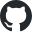

    GitHub

    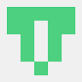

*   [](https://stackoverflow.com/questions/33971851/what-happens-when-rdma-operates-over-mmaped-region)

    What happens when RDMA operates over mmaped region?

    Nov 28, 2015 — What happens when RDMA operates over mmaped region? ... RDMA is an efficient way to bypass the useless data copies between applica...

    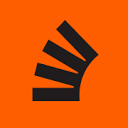

    Stack Overflow

*   [](https://www.oracle.com/database/technologies/exadata/hardware/rdmanetwork/#:~:text=RDMA%20\(Remote%20Direct%20Memory%20Access,and%20with%20very%20low%20latency.)

    RDMA Network Fabric | Oracle Exadata Database Machine

    RDMA (Remote Direct Memory Access) allows one computer to directly access data from another without operating system or CPU involv...

    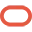

    Oracle


Show all
